In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score



In [3]:
df = pd.read_csv('Life Expectancy Data.csv')  # Load the dataset
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


EDA

In [4]:
df.shape

(2938, 22)

In [5]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [6]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [7]:
df.isnull().sum()           # Check for missing values

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [8]:
# removing leading and trailing spaces from column names
df.columns = df.columns.str.strip()

In [9]:
# Treat missing values (for simplicity, we'll fill them with the mean of each column)

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
  df[col] = df[col].fillna(df[col].mean())
    

In [10]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

Text(0, 0.5, 'Frequency')

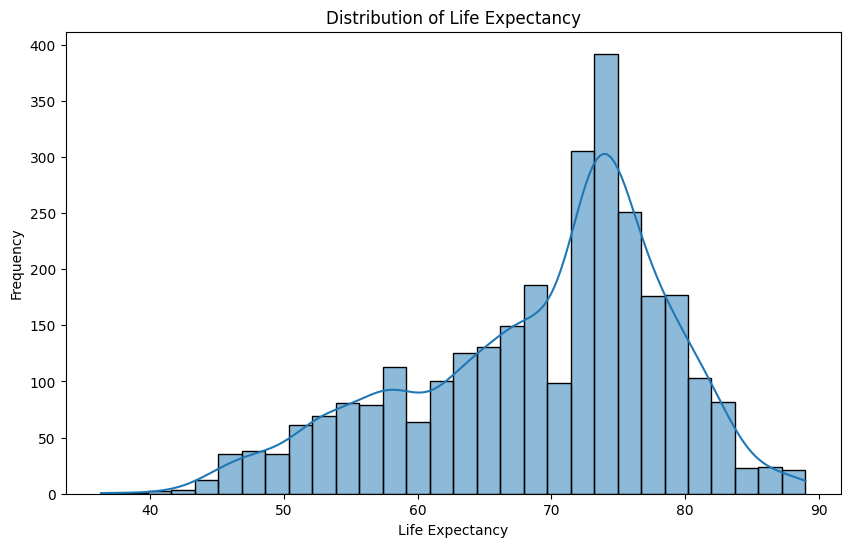

In [40]:
# Visualization

# Histogram

plt.figure(figsize=(10, 6))
sns.histplot(df['Life expectancy '], bins=30, kde=True)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')

Interpretation:

This histogram shows life expectancy on X axis and Frequency on Y axis

X axis: It shows life expectancy values
Exampple: 
40 years
50 years
60 years
70 years

Y axis: It shows frequency which means how many countries or data points fall within a particular life expectancy range

Higher Bars: It means more countries have those values
Lower Bars: It means fewer countries have those values

This histogram shows the distribution of life expectancy values in the dataset. Most countries have life expectancy between 70 to 75 years, which shows that the data is concentrated around this range. The distribution is slightly left skewed, which mean there are few countries have significantly lower life expectancy values. Very high and very low values occur less frequently. The KDE curve helps visualize the overall  distribution pattern smoothly.
          

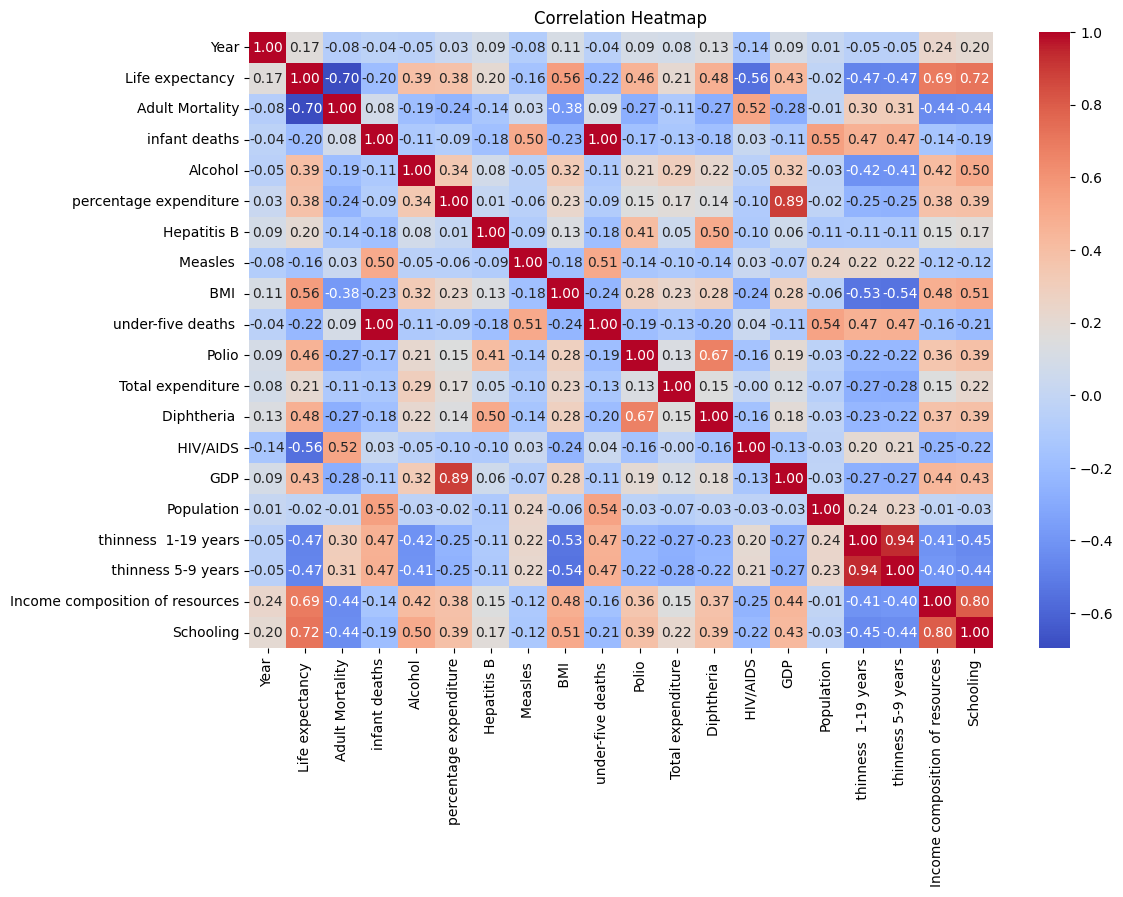

In [41]:
# Heatmap

plt.figure(figsize=(12, 8))
correlation = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Interpretation:

The heatmap correlation shows the relationship between numerical variables in the dataset. Positive correlation indicates that both variables increase together and negative correlation indicate that one variable increases and other variable decreases. Life expectancy has strong positive correlation with schooling(0.72) and income composition of resources(0.69), while it has negative correlation with Adult mortality(-0.70) and HIV/AIDS(-0.56). The heatmap helps identify the important features affecting life expectancy and shows relationships among variables visually.

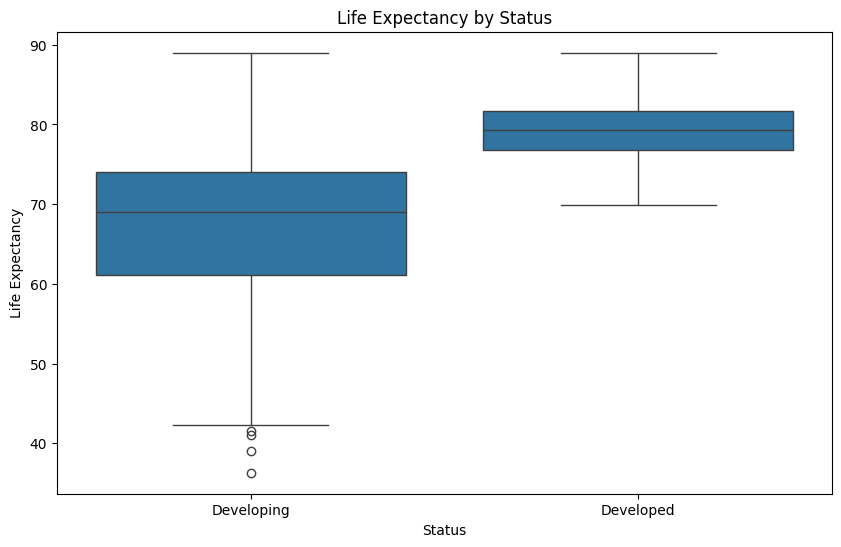

In [42]:
# Boxplot

plt.figure(figsize=(10, 6))
sns.boxplot(x='Status', y='Life expectancy ', data=df)
plt.title('Life Expectancy by Status')
plt.xlabel('Status')
plt.ylabel('Life Expectancy')
plt.show()

Interpretation:

The boxplot compares life expectancy between developing and developed countries. Developed countries have have a higher median life expectancy 79 to 80 years, while developing countries have a lower median around 69 years. Developing countries also show greater variability and several low outliers, indicating that some countries have extremely low life expectancy. Developed countries have a  more consistent  distribution. This visualization clearly shows the gap  in healthcare and living conditions between developed and developing countries.

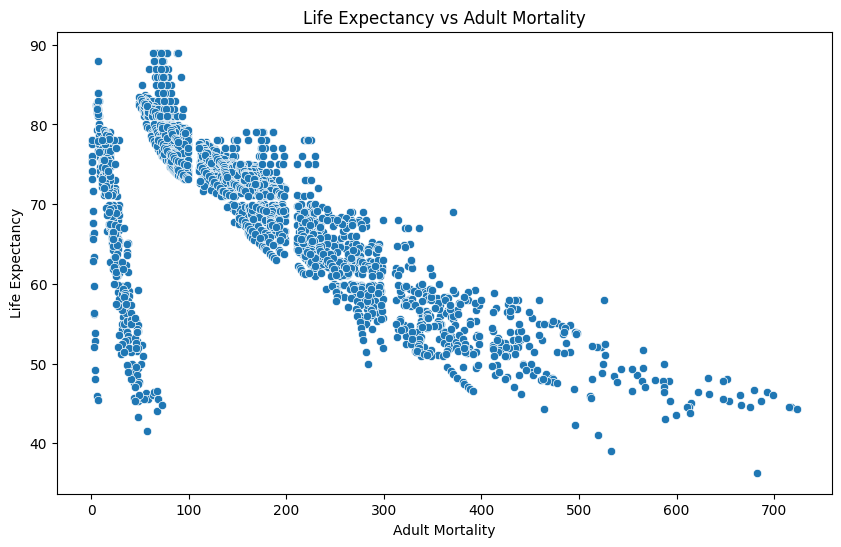

In [43]:
# Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Adult Mortality', y='Life expectancy ', data=df)
plt.title('Life Expectancy vs Adult Mortality')
plt.xlabel('Adult Mortality')
plt.ylabel('Life Expectancy')
plt.show()

Interpretation:

This scatter plot shows the realtionship between Adult Moratality and Life Expectancy. We can see that as Adult Mortality increases, Life Expectancy tends to decrease, indicating a negative correlation between the two variables. This suggests that higher adult mortality rates are associated with lower life expectancy. It also supports the correlation analysis from heatmap.

In [44]:
# Checking for skewness and will transform if necessary

df.columns = df.columns.str.strip()  # Remove leading/trailing spaces from column names

numeric_cols = df.select_dtypes(include=[np.number])    # Select only numeric columns

print("Skewness before transformation:\n")
print(numeric_cols.skew())




Skewness before transformation:

Year                               -0.006409
Life expectancy                    -0.639693
Adult Mortality                     1.176371
infant deaths                       9.786963
Alcohol                             0.610026
percentage expenditure              4.652051
Hepatitis B                        -2.142780
Measles                             9.441332
BMI                                -0.220590
under-five deaths                   9.495065
Polio                              -2.104863
Total expenditure                   0.643921
Diphtheria                         -2.079481
HIV/AIDS                            5.396112
GDP                                 3.482880
Population                         18.041176
thinness  1-19 years                1.721451
thinness 5-9 years                  1.787788
Income composition of resources    -1.177688
Schooling                          -0.619859
dtype: float64


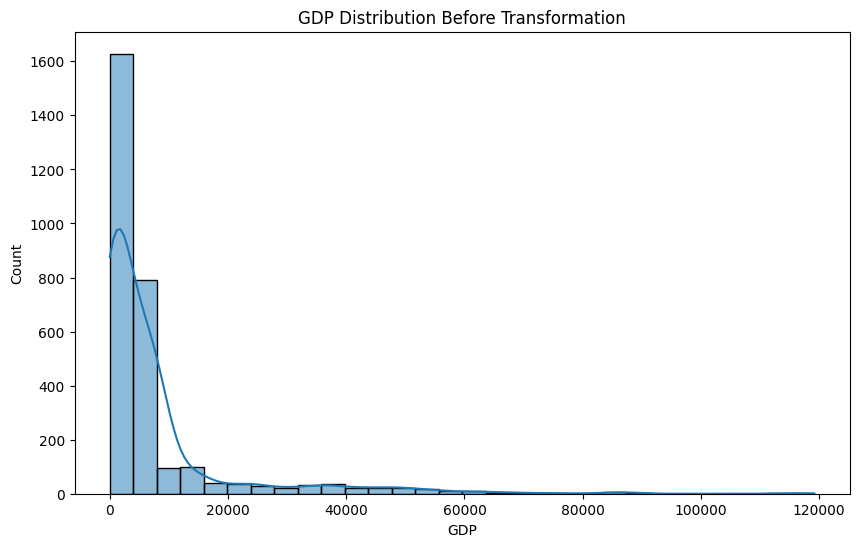

In [45]:
plt.figure(figsize=(10, 6))               # Visualize the distribution of GDP before transformation
sns.histplot(df["GDP"], bins=30, kde=True)
plt.title('GDP Distribution Before Transformation')
plt.show()

In [46]:
skewed_cols = numeric_cols.columns[numeric_cols.skew() > 1]    # Identify skewed columns which need to be transformed

In [47]:
for col in skewed_cols:
    df[col] = np.log1p(df[col])    # Apply log transformation to reduce skewness

In [48]:
print("Skewness after transformation:\n")
print(df[skewed_cols].skew())

Skewness after transformation:

Adult Mortality          -1.131225
infant deaths             0.701769
percentage expenditure   -0.078266
Measles                   0.555483
under-five deaths         0.647154
HIV/AIDS                  2.127285
GDP                      -0.425071
Population               -0.939418
thinness  1-19 years      0.125769
thinness 5-9 years        0.097877
dtype: float64


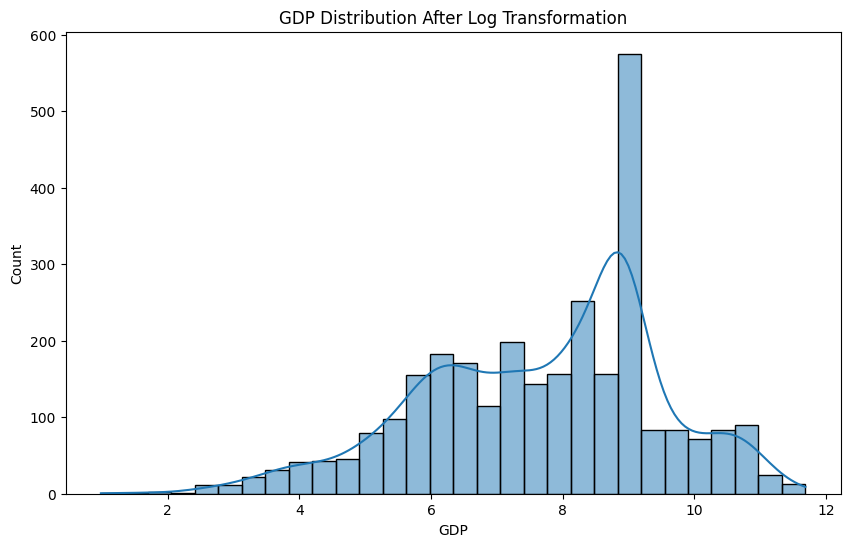

In [49]:
plt.figure(figsize=(10, 6))
sns.histplot(df['GDP'], bins=30, kde=True)
plt.title('GDP Distribution After Log Transformation')
plt.show()

Skewness was checked for numerical variables to identify non normal distribution. Highly skewed variables such as GDP, Population and Percentage Expenditure showed long right tails due to extreme values. Log transformation using log1p() was applied to reduce skewness and make the distributions more balanced. This helps improve model performance and reduces the influence of outliers.

<Figure size 1500x1000 with 0 Axes>

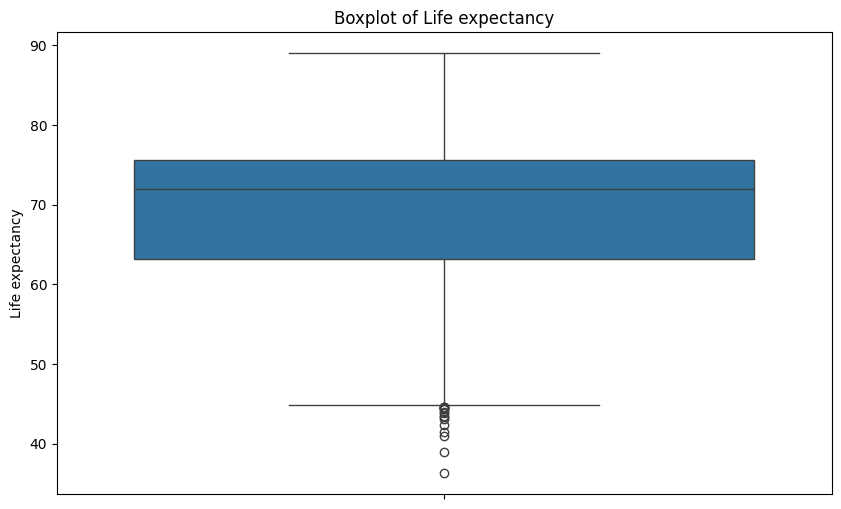

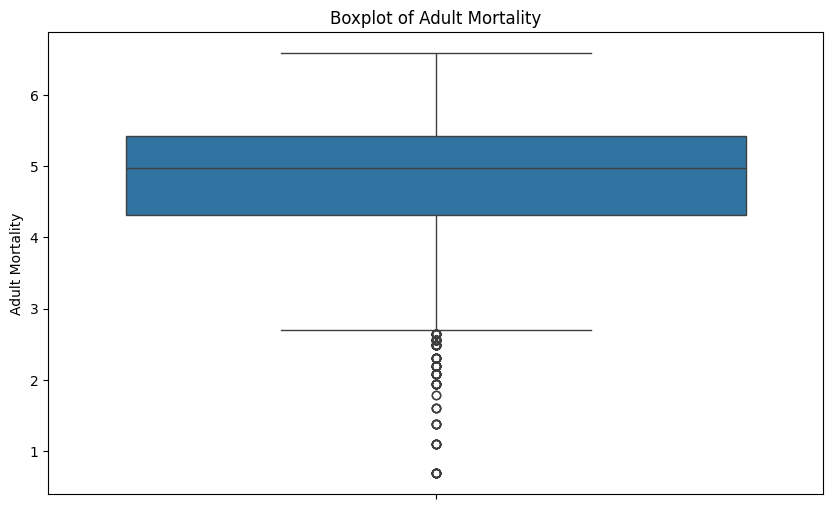

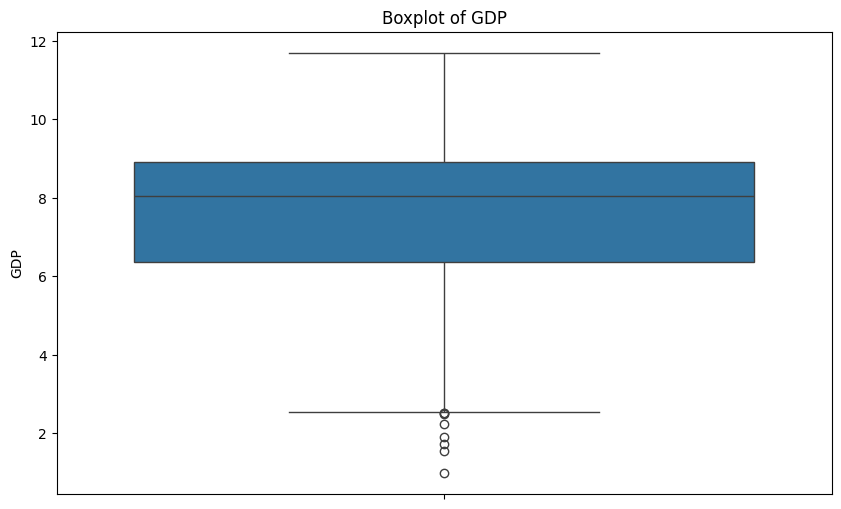

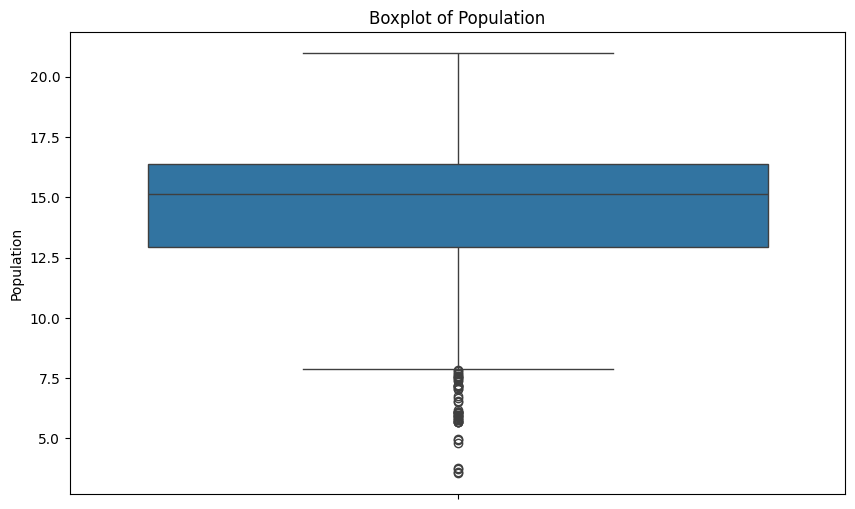

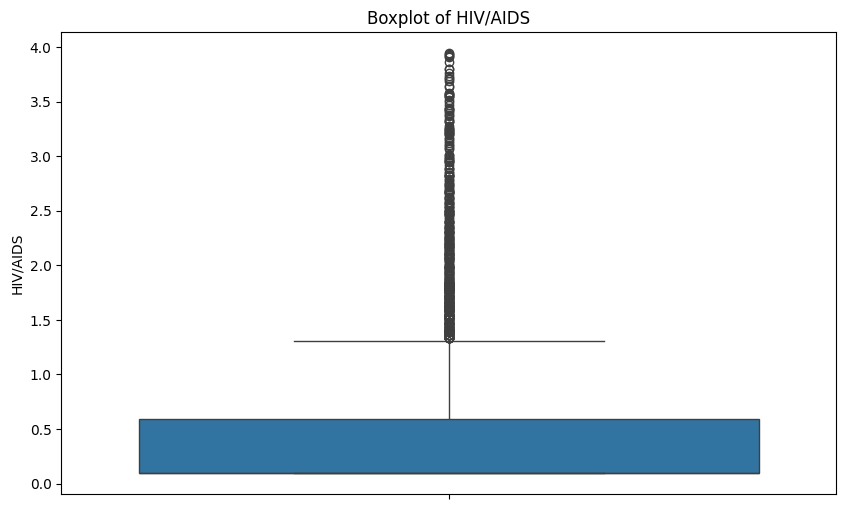

In [50]:
# Checking for outliers using boxplot

selected_cols = ['Life expectancy', 'Adult Mortality', 'GDP', 'Population', 'HIV/AIDS']     # Select columns to check for outliers
plt.figure(figsize=(15, 10))

for col in selected_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [51]:
# Removing Outliers using IQR method

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    

<Figure size 1500x1000 with 0 Axes>

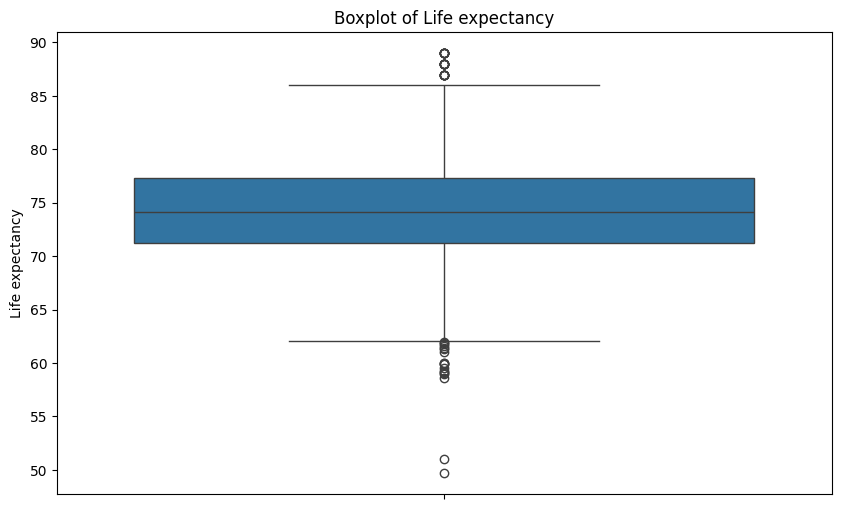

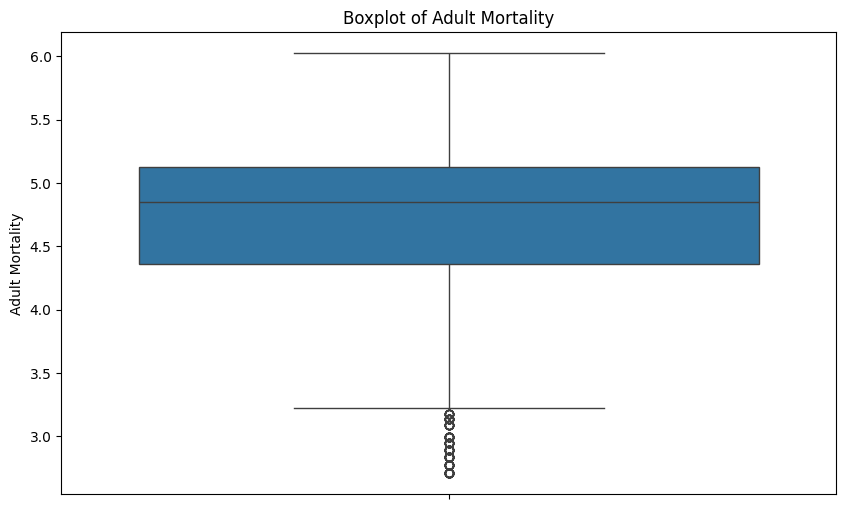

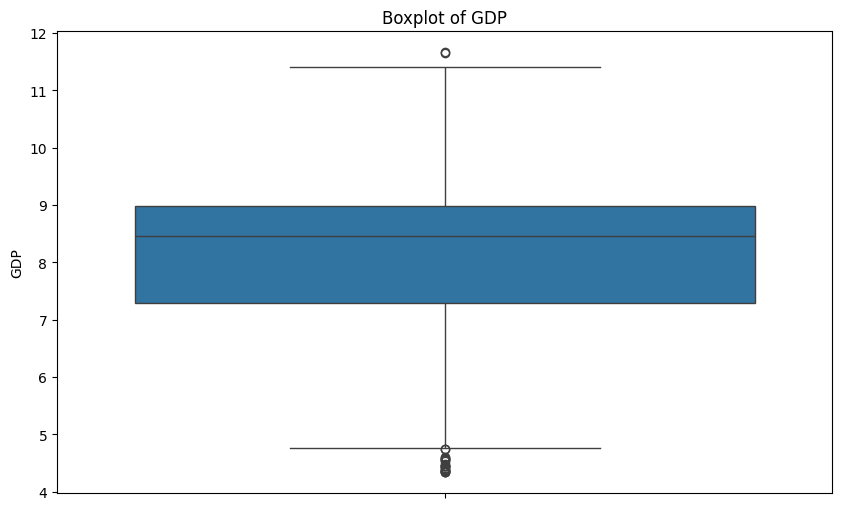

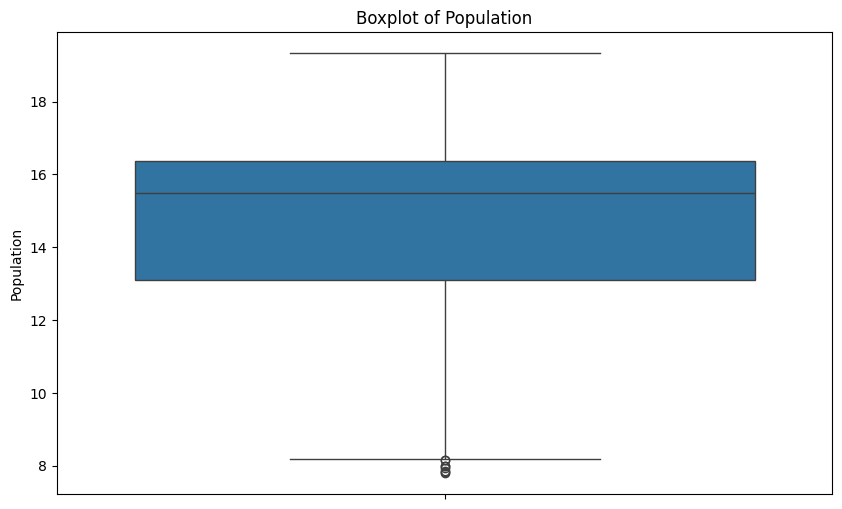

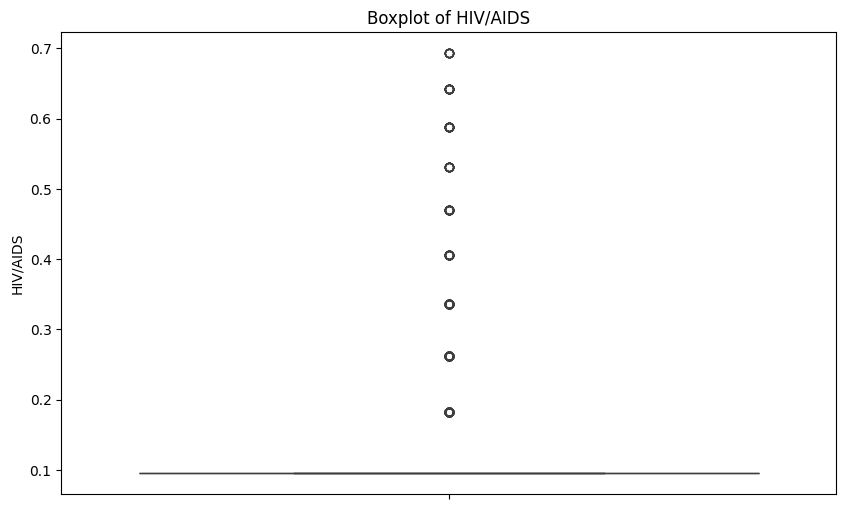

In [52]:
# Checking for outliers using boxplot

selected_cols = ['Life expectancy', 'Adult Mortality', 'GDP', 'Population', 'HIV/AIDS']     # Select columns to check for outliers
plt.figure(figsize=(15, 10))

for col in selected_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Outliers were visually checked using boxplot for selected numerical variables such as GDP, Population, Life Expectancy, Adult Mortality, HIV/AIDS because these features showed high skewness and extreme values. However, outlier treatment using the IQR method was applied to all numerical  columns programmatically to ensure complete preprocessing of the dataset.

In [53]:
countries = sorted(df["Country"].dropna().unique())

status_values = sorted(df["Status"].dropna().unique())

pickle.dump(countries, open("countries.pkl", "wb"))

pickle.dump(status_values, open("status.pkl", "wb"))

In [54]:
# Encode the categorical variable using get_dummies

df = pd.get_dummies(df, drop_first=True)

In [55]:
# Seperate features and target variable
 
x = df.drop('Life expectancy', axis=1)    # Features
y = df['Life expectancy']                 # Target variable

In [56]:
model_columns = x.columns.tolist()
pickle.dump(model_columns, open('model_columns.pkl', 'wb'))

In [57]:
# Train-Test Split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [58]:
# Feature Scaling


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [59]:
# Models

model = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'XGBoost': XGBRegressor()
}

In [60]:
# Compare models

results = []

for name, model in model.items():
    model.fit(x_train_scaled, y_train)    # Train the model
    y_test_pred = model.predict(x_test_scaled) # Predict on the test set
    
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'Test_R2 Score': test_r2})

In [61]:
result_df = pd.DataFrame(results)
result_df

,Model,MAE,MSE,Test_R2 Score
0,Linear Regression,1.092943,3.365381,0.895792
1,Random Forest,0.996735,2.964279,0.908212
2,Decision Tree,1.299674,5.570293,0.827518
3,KNN,1.564740,7.082588,0.780691
4,SVR,1.412051,8.144519,0.747809
5,XGBoost,1.034673,2.985247,0.907563


In [62]:
# Have to check for the overfitting
# check for Train R2 score

y_train_pred = model.predict(x_train_scaled)
train_r2 = r2_score(y_train, y_train_pred)



In [63]:
# Overfitting Status
model = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'XGBoost': XGBRegressor()
}


overfitting_result = []

for name, model in model.items():
  
  model.fit(x_train_scaled, y_train)    # Train the model

  y_train_pred = model.predict(x_train_scaled) # Predict on the training set
  y_test_pred = model.predict(x_test_scaled) # Predict on the test set

  train_r2 = r2_score(y_train, y_train_pred) # Calculate R2 score for training set
  test_r2 = r2_score(y_test, y_test_pred)    # Calculate R2 score for test set
  

  difference = train_r2 - test_r2             # Difference between training and test R2 scores

  if difference > 0.1:                       # Overfitting check
    status = "Overfitting"
  else:
    status = "Good Fit"

  overfitting_result.append({                        # Store the results in a dictionary
    'Model': name,
    'Train R2 Score': train_r2,
    'Test R2 Score': test_r2,
    'R2 Score Difference': difference,
    'Overfitting Status': status
     })

overfitting_status_df = pd.DataFrame(overfitting_result)
overfitting_status_df



,Model,Train R2 Score,Test R2 Score,R2 Score Difference,Overfitting Status
0,Linear Regression,0.922573,0.895792,0.026781,Good Fit
1,Random Forest,0.987370,0.909834,0.077536,Good Fit
2,Decision Tree,1.000000,0.849235,0.150765,Overfitting
3,KNN,0.913914,0.780691,0.133223,Overfitting
4,SVR,0.858383,0.747809,0.110575,Overfitting
5,XGBoost,0.997308,0.907563,0.089745,Good Fit


In [64]:
import sys                                 # Check the Python executable path to install XGBoost
print(sys.executable)


c:\Data Science\Deployment\Life_Expectancy_Prediction\life_pred_env\python.exe


In [65]:
# Creating model using Linear Regression

lr_model = LinearRegression()

In [66]:
lr_model.fit(x_train_scaled, y_train)    # Train the model
y_test_pred = lr_model.predict(x_test_scaled) # Predict on the test set

In [67]:
joblib.dump(lr_model, 'life_expectancy_model.pkl')    # Save the model using joblib
joblib.dump(scaler, 'scaler.pkl')    # Save the scaler using joblib


['scaler.pkl']

In [68]:
loaded_model = joblib.load('life_expectancy_model.pkl')    # Load the model
loaded_scaler = joblib.load('scaler.pkl')    # Load the scaler